================================================================================
##### DATATOUR 2025 - PRÉDICTION DU DÉFAUT DE PAIEMENT
================================================================================

- Objectif : Développer un modèle de classification binaire pour prédire les défauts de paiement (classe 0 = normal, classe 1 = défaut)
- Métrique : ROC AUC Score
- Approche : LightGBM DART avec gestion du déséquilibre des classes

================================================================================

--------------------------------------------------------------------------------
#### SECTION 0 : INSTALLATION DES DÉPENDANCES
--------------------------------------------------------------------------------

In [ ]:
# Installation de df_squeezer pour l'optimisation mémoire des DataFrames
#!pip install df-squeezer

# Importation des bibliothèques de base pour la manipulation de données
import numpy as np
import pandas as pd 
import seaborn as sn

# Importation de l'outil d'optimisation mémoire
from df_squeezer import df_squeezer

# Installation des packages nécessaires pour le machine learning
#!pip install "ipython>=8.20"
#!pip install imblearn
#!pip install lightgbm
#!pip install xgboost
#!pip install catboost

# Activation du rechargement automatique des modules modifiés
%load_ext autoreload
%autoreload 2

# Importation des bibliothèques essentielles
import gc
import os
import sys
import pandas as pd
import numpy as np
import tqdm
import seaborn as sns

# Configuration de matplotlib pour l'affichage des graphiques
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# Importation des outils de scikit-learn pour la validation et l'évaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

# Configuration de l'affichage pandas pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

# Configuration de l'environnement CUDA pour l'utilisation du GPU si disponible
os.environ["CUDA_VISIBLE_DEVICES"] = '0'

sys.path.append('../')

--------------------------------------------------------------------------------
#### SECTION 1 : CHARGEMENT DES DONNÉES
--------------------------------------------------------------------------------


In [9]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")

In [10]:
train.head()

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,flag
0,1678548,3,8,7,17,16,9,1,9,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,3,2,1,0,0,0
1,2834188,11,3,2,0,7,14,8,2,5,1,0,2,13,6,16,5,4,8,1,0,1,1,1,1,2,17,0,1,1,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,2,4,1,0,0,0
2,811902,11,9,6,11,13,14,8,2,5,1,0,2,11,6,16,5,4,8,1,1,1,1,1,11,2,17,0,1,1,0,0,0,0,0,0,0,0,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0,0
3,836450,1,16,0,13,0,4,9,5,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,0
4,1769024,15,9,9,4,8,1,11,1,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,1,0


--------------------------------------------------------------------------------
#### SECTION 2 : OPTIMISATION MÉMOIRE
--------------------------------------------------------------------------------

##### Application de l'optimisation sur le jeu d'entraînement

In [11]:
df_squeezer(train, edit=True, report=False)

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,flag
0,1678548,3,8,7,17,16,9,1,9,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,3,2,1,0,0,0
1,2834188,11,3,2,0,7,14,8,2,5,1,0,2,13,6,16,5,4,8,1,0,1,1,1,1,2,17,0,1,1,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,2,4,1,0,0,0
2,811902,11,9,6,11,13,14,8,2,5,1,0,2,11,6,16,5,4,8,1,1,1,1,1,11,2,17,0,1,1,0,0,0,0,0,0,0,0,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0,0
3,836450,1,16,0,13,0,4,9,5,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,0
4,1769024,15,9,9,4,8,1,11,1,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17659828,2103608,4,1,9,4,8,1,11,10,2,4,0,2,2,6,16,5,4,8,1,1,1,1,1,10,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,1,1,0
17659829,2169551,7,15,4,12,10,6,13,15,2,3,0,2,2,6,16,5,4,8,1,0,1,1,1,16,2,17,1,1,1,0,0,1,0,0,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,1,3,2,1,0,0,0
17659830,1613436,1,8,9,16,5,9,9,10,3,3,0,2,10,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,0
17659831,1604231,6,17,13,12,1,2,4,2,2,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,3,0,1,0,0,0


##### Application de l'optimisation sur le jeu de test

In [12]:
df_squeezer(test, edit=True, report=False)

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,id_x_rn
0,1472943,2,10,4,16,16,13,10,10,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,1472943_x_2
1,660465,5,6,14,9,7,3,11,0,2,3,0,2,4,6,16,5,4,8,1,0,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,1,0,1,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,660465_x_5
2,1788193,3,1,0,9,9,7,2,16,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,1788193_x_3
3,2767146,3,15,8,1,16,6,13,14,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,9,5,4,0,0,0,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,3,1,0,0,2767146_x_3
4,2601698,9,19,10,4,8,1,11,4,2,3,0,2,2,6,16,5,4,8,1,1,1,1,1,9,5,4,0,0,0,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,1,1,2601698_x_9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654063,2159273,7,9,1,15,9,1,11,6,2,3,0,2,0,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,2159273_x_7
654064,320081,7,0,4,3,5,6,13,13,2,3,0,2,4,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,320081_x_7
654065,2663677,4,15,4,1,15,13,13,7,5,3,0,2,2,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,3,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0,2663677_x_4
654066,1382804,18,11,16,11,13,14,8,14,0,5,0,2,1,6,16,5,4,8,1,0,1,1,1,1,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,0,0,3,4,1,2,4,1,0,0,1382804_x_18


--------------------------------------------------------------------------------
#### SECTION 3 : ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
--------------------------------------------------------------------------------

##### Vérification des valeurs nulles dans chaque colonne

In [ ]:
#Vérification des valeurs nulles
train.isnull().sum()

,0
id,0
rn,0
pre_since_opened,0
pre_since_confirmed,0
pre_pterm,0
...,...
enc_loans_credit_type,0
enc_loans_account_cur,0
pclose_flag,0
fclose_flag,0


##### Vérification des doublons dans le dataset

In [ ]:
#Vérification des doublons
train.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
17659828,False
17659829,False
17659830,False
17659831,False


##### Analyse de la distribution de la variable cible

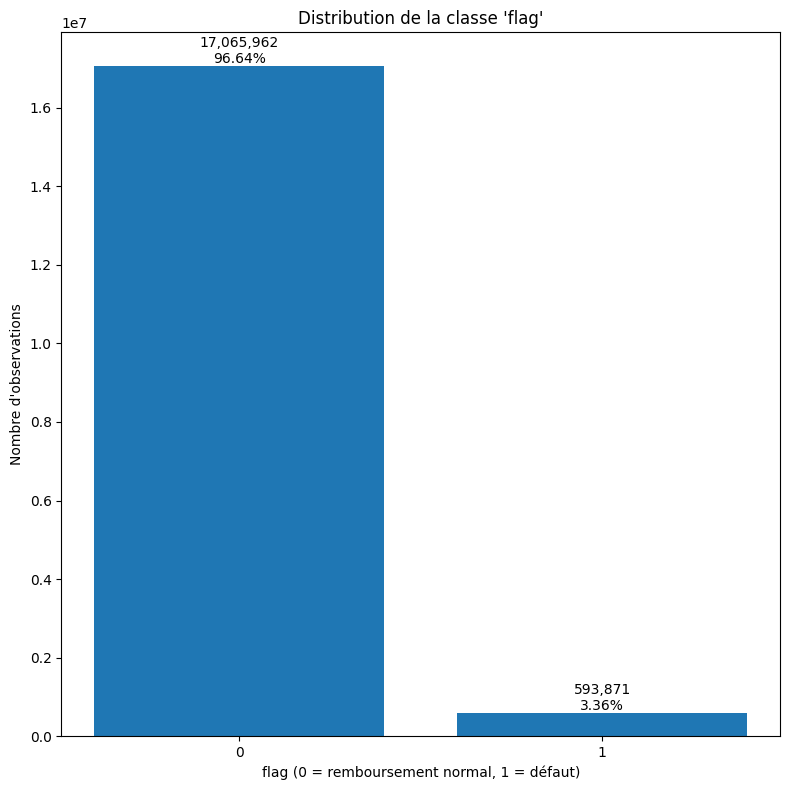

In [ ]:
# Calcul du nombre d'observations par classe
vc = train["flag"].value_counts(dropna=False).sort_index()

# Calcul du pourcentage de chaque classe
pct = vc / vc.sum() * 100

# Création d'un graphique à barres pour visualiser la distribution
fig, ax = plt.subplots(figsize=(8, 8))
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("Distribution de la classe 'flag'")
ax.set_xlabel("flag (0 = remboursement normal, 1 = défaut)")
ax.set_ylabel("Nombre d'observations")

# Ajout des annotations (nombre d'observations et pourcentage) sur chaque barre
for i, (cls, cnt) in enumerate(vc.items()):
    ax.text(i, cnt, f"{cnt:,}\n{pct.loc[cls]:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()


--------------------------------------------------------------------------------
#### SECTION 4 : GESTION DU DÉSÉQUILIBRE DES CLASSES
--------------------------------------------------------------------------------

##### Les données sont trop déséquilibrées, on les ramène à la même distribution
##### Stratégie : UNDERSAMPLING de la classe majoritaire (classe 0)
##### Objectif : Équilibrer les classes à 50/50 pour éviter le biais du modèle

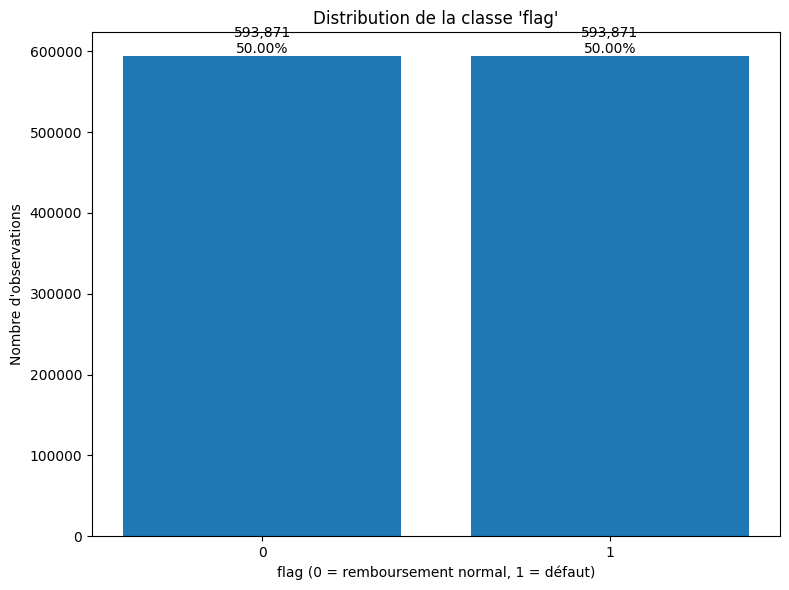

In [ ]:
# Calcul du nombre d'observations de la classe minoritaire (défauts)
n_pos = (train["flag"] == 1).sum()

# Création d'un dataset équilibré en combinant :
# - Toutes les observations de la classe 1 (défauts)
# - Un échantillon aléatoire de n_pos observations de la classe 0 (normaux)
train_under = pd.concat([
    train[train["flag"] == 1],
    train[train["flag"] == 0].sample(n=n_pos, random_state=42, replace=False)
]).sample(frac=1.0, random_state=42).reset_index(drop=True)

# Visualisation de la nouvelle distribution équilibrée
vc = train_under["flag"].value_counts(dropna=False).sort_index()
pct = vc / vc.sum() * 100

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("Distribution de la classe 'flag'")
ax.set_xlabel("flag (0 = remboursement normal, 1 = défaut)")
ax.set_ylabel("Nombre d'observations")

# Annotations : Nombre et pourcentage
for i, (cls, cnt) in enumerate(vc.items()):
    ax.text(i, cnt, f"{cnt:,}\n{pct.loc[cls]:.2f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

-------------------------------------------------------------------------------
#### SECTION 5 : BENCHMARK DES MODÈLES
--------------------------------------------------------------------------------

##### Malgré le undersampling les données sont toujours très volumineux. Nous définissons un échantillon sur lequel tester nos modèles. Cette approche permet de comparer rapidement plusieurs algorithmes

In [ ]:
# Extraction d'un échantillon de 10% du dataset équilibré pour les tests rapides
df_small = train_under.sample(frac=0.10, random_state=42).reset_index(drop=True)

In [ ]:
# Séparation des features (X) et de la cible (y)
X = df_small.drop('flag', axis=1)
y = df_small['flag']

# Division du dataset en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (95019, 61)
X_test shape: (23755, 61)
y_train shape: (95019,)
y_test shape: (23755,)


In [ ]:
# Importation des algorithmes de machine learning pour le benchmark

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier,HistGradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV
from lightgbm import LGBMClassifier
from scipy.stats import wilcoxon
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline as SkPipe
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


##### Fonction de Benchmark des modèles

Nous évaluons l'échantillon sur un ensemble de modèles afin de déterminer lequel utiliser pour le modèle final

In [ ]:
# Vérification de la disponibilité des packages optionnels

try:
    from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
    HAS_IMB = True
except Exception:
    HAS_IMB = False

# --- GBDTs ---
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

try:
    from xgboost import XGBClassifier, XGBRFClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from catboost import CatBoostClassifier
    HAS_CAT = True
except Exception:
    HAS_CAT = False


def train_and_evaluate_models_alt(X_train, y_train, random_state=42, n_splits=5):
    """
    Benchmark de modèles potentiellement plus performants sur tabulaire:
    - BalancedRandomForest, EasyEnsemble (imblearn)
    - LGBM (dart, goss), XGBRF, CatBoost
    - HistGB calibré, ExtraTrees
    - Stacking (LogReg méta)
    """
    models = {}

    # 1) Ensembles "imbalance-aware"
    if HAS_IMB:
        models["Balanced Random Forest"] = BalancedRandomForestClassifier(
            n_estimators=500, n_jobs=-1, random_state=random_state
        )
        models["Easy Ensemble (AdaBoost)"] = EasyEnsembleClassifier(
            n_estimators=50, random_state=random_state, n_jobs=-1
        )

    # 2) Variantes GBDT
    if HAS_LGBM:
        # LGBM - DART (dropouts meet multiple additive regression trees)
        models["LightGBM (dart)"] = LGBMClassifier(
            boosting_type="dart",
            n_estimators=1200,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary",
            n_jobs=-1,
            random_state=random_state,
        )
        # LGBM - GOSS (Gradient-based One-Side Sampling)
        models["LightGBM (goss)"] = LGBMClassifier(
            boosting_type="goss",
            n_estimators=1200,
            learning_rate=0.05,
            num_leaves=64,
            colsample_bytree=0.8,
            objective="binary",
            n_jobs=-1,
            random_state=random_state,
        )

    if HAS_XGB:
        # XGBRF: forêt randomisée de XGBoost (souvent robuste, différent du GBDT classique)
        models["XGBRF"] = XGBRFClassifier(
            n_estimators=1000,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            eval_metric="auc",
            n_jobs=-1,
            random_state=random_state
        )
        # Optionnel: si tu veux aussi un GBDT XGBoost classique:
        models["XGBoost (hist)"] = XGBClassifier(
            n_estimators=1200,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            eval_metric="auc",
            tree_method="hist",  # "gpu_hist" si GPU dispo
            n_jobs=-1,
            random_state=random_state
        )

    if HAS_CAT:
        models["CatBoost"] = CatBoostClassifier(
            iterations=1200,
            depth=8,
            learning_rate=0.05,
            loss_function="Logloss",
            eval_metric="AUC",
            random_state=random_state,
            verbose=False
        )

    # 3) Baselines rapides et un stacking simple
    models["Extra Trees"] = ExtraTreesClassifier(
        n_estimators=600, n_jobs=-1, random_state=random_state
    )
    models["HistGradientBoosting (calibré)"] = HistGradientBoostingClassifier(
        max_depth=None, learning_rate=0.08, max_iter=800, random_state=random_state
    )

    # Stacking (métamodèle LogReg)
    base_estimators = []
    if "Extra Trees" in models:
        base_estimators.append(("et", models["Extra Trees"]))
    if HAS_LGBM:
        base_estimators.append(("lgbm_dart", models.get("LightGBM (dart)")))
    if HAS_XGB:
        base_estimators.append(("xgbrf", models.get("XGBRF")))
    if HAS_CAT:
        base_estimators.append(("cat", models.get("CatBoost")))
    if base_estimators:
        models["Stacking (LogReg meta)"] = StackingClassifier(
            estimators=[(n, m) for (n, m) in base_estimators if m is not None],
            final_estimator=LogisticRegression(
                solver="lbfgs", max_iter=2000, n_jobs=-1, random_state=random_state
            ),
            stack_method="predict_proba",
            n_jobs=-1,
            passthrough=False
        )

    # ========= Évaluation des modèles=========
    # Validation croisée stratifiée
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    roc_curves = {}
    conf_matrices = {}
    all_results = []

    for model_name, model in models.items():
        y_true_all, y_pred_all, y_prob_all = [], [], []

        for tr_idx, te_idx in kf.split(X_train, y_train):
            X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
            y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

            # --- Fit (avec eval_set si dispo) ---
            if HAS_LGBM and isinstance(model, LGBMClassifier):
                model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_te, y_te)],
                    eval_metric="auc",
                    # early_stopping_rounds=100,  # décommente si tu veux
                )
            elif HAS_XGB and isinstance(model, (XGBClassifier, XGBRFClassifier)):
                model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_te, y_te)],
                    verbose=False
                    # early_stopping_rounds=100,  # décommente si tu veux
                )
            elif HAS_CAT and isinstance(model, CatBoostClassifier):
                model.fit(
                    X_tr, y_tr,
                    eval_set=[(X_te, y_te)],
                    verbose=False
                    # use_best_model=True
                )
            else:
                model.fit(X_tr, y_tr)

            # --- Probas & prédictions ---
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_te)[:, 1]
            else:
                # fallback pour rares cas
                y_score = model.decision_function(X_te)
                y_prob = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-9)
            y_pred = model.predict(X_te)

            y_true_all.extend(y_te); y_pred_all.extend(y_pred); y_prob_all.extend(y_prob)

        # Metrics globalisées
        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)
        y_prob_all = np.array(y_prob_all)

        accuracy = accuracy_score(y_true_all, y_pred_all)
        precision = precision_score(y_true_all, y_pred_all, zero_division=0)
        recall = recall_score(y_true_all, y_pred_all)
        f1 = f1_score(y_true_all, y_pred_all)
        roc_auc = roc_auc_score(y_true_all, y_prob_all)

        all_results.append({
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1 Score': f1,
            'ROC AUC': roc_auc,
        })

        fpr, tpr, _ = roc_curve(y_true_all, y_prob_all)
        roc_curves[model_name] = (fpr, tpr, roc_auc)
        conf_matrices[model_name] = confusion_matrix(y_true_all, y_pred_all)

    results_df = pd.DataFrame(all_results)

    # ROC plots
    plt.figure(figsize=(10, 8))
    for model_name, (fpr, tpr, auc_v) in roc_curves.items():
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_v:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (Alternatives)')
    plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

    # Confusion matrices grid
    num_models = len(models)
    cols = 3
    rows = num_models // cols + int(num_models % cols > 0)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))
    axes = np.array(axes).reshape(-1)
    for idx, (model_name, cm) in enumerate(conf_matrices.items()):
        ax = axes[idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(f'Confusion Matrix - {model_name}')
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for idx in range(len(conf_matrices), len(axes)):
        fig.delaxes(axes[idx])
    plt.tight_layout(); plt.show()

    # Tri des résultats par ROC AUC décroissant
    sorted_results_df = results_df.sort_values('ROC AUC', ascending=False).reset_index(drop=True)
    display(sorted_results_df)
    return sorted_results_df


[LightGBM] [Info] Number of positive: 38185, number of negative: 37830
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003396 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 681
[LightGBM] [Info] Number of data points in the train set: 76015, number of used features: 59
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502335 -> initscore=0.009340
[LightGBM] [Info] Start training from score 0.009340
[LightGBM] [Info] Number of positive: 38185, number of negative: 37830
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.045881 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 682
[LightGBM] [Info] Number of data points in the train set: 76015, number of used features: 59
[LightGBM] [Info] [bin

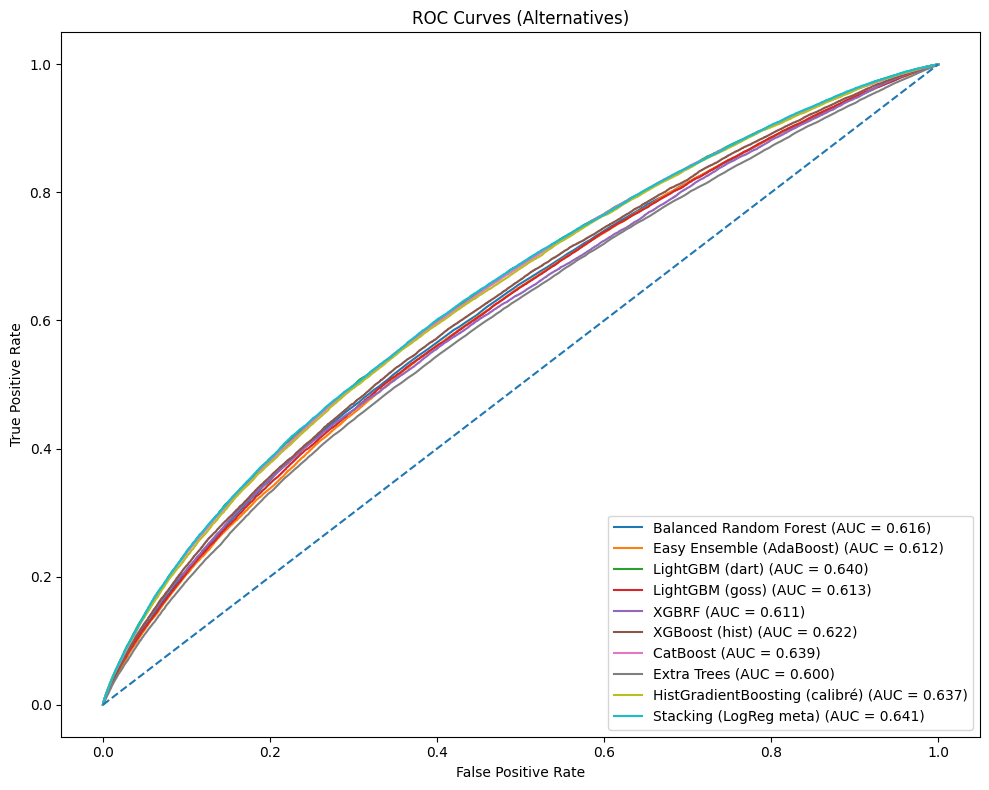

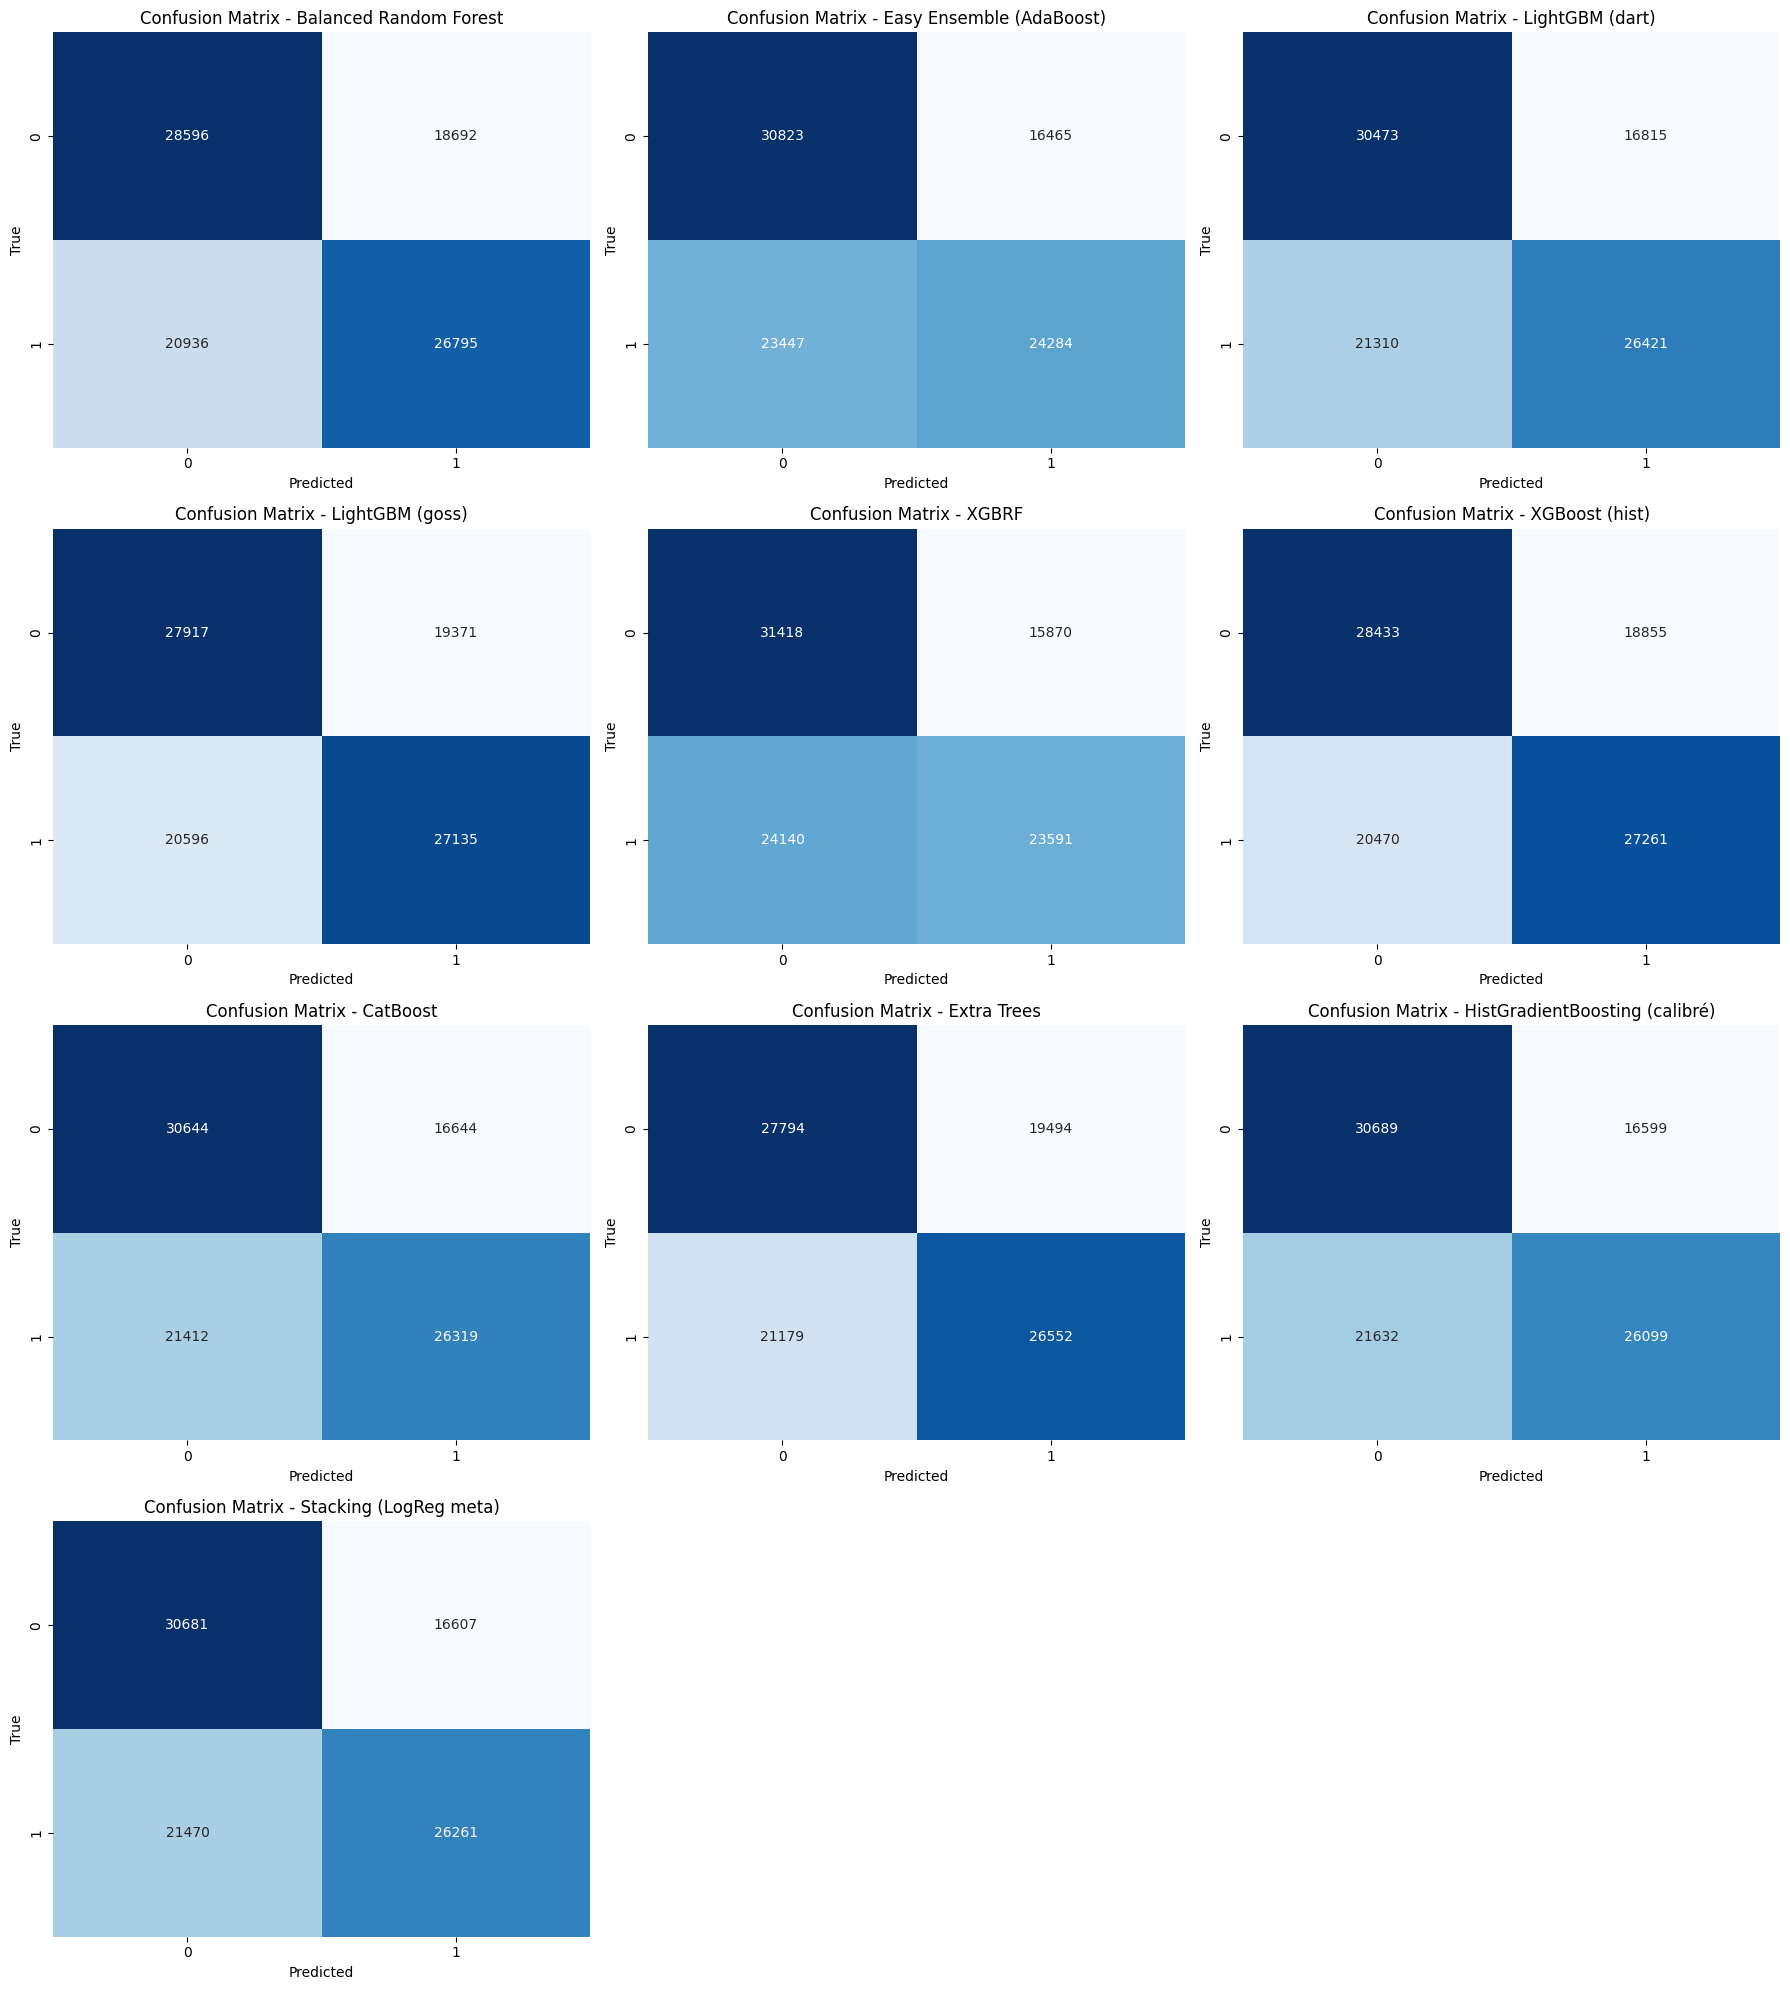

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Stacking (LogReg meta),0.599270,0.612601,0.550188,0.579719,0.641188
1,LightGBM (dart),0.598764,0.611088,0.553540,0.580892,0.640486
2,CatBoost,0.599491,0.612597,0.551403,0.580391,0.639126
3,HistGradientBoosting (calibré),0.597649,0.611246,0.546793,0.577226,0.636783
4,XGBoost (hist),0.586135,0.591140,0.571138,0.580967,0.621676
5,Balanced Random Forest,0.582947,0.589069,0.561375,0.574889,0.615967
6,LightGBM (goss),0.579379,0.583473,0.568498,0.575888,0.613270
7,Easy Ensemble (AdaBoost),0.579958,0.595941,0.508768,0.548915,0.611863
8,XGBRF,0.578926,0.597831,0.494249,0.541128,0.610861
9,Extra Trees,0.571949,0.576641,0.556284,0.566280,0.599780


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Stacking (LogReg meta),0.599270,0.612601,0.550188,0.579719,0.641188
1,LightGBM (dart),0.598764,0.611088,0.553540,0.580892,0.640486
2,CatBoost,0.599491,0.612597,0.551403,0.580391,0.639126
3,HistGradientBoosting (calibré),0.597649,0.611246,0.546793,0.577226,0.636783
4,XGBoost (hist),0.586135,0.591140,0.571138,0.580967,0.621676
5,Balanced Random Forest,0.582947,0.589069,0.561375,0.574889,0.615967
6,LightGBM (goss),0.579379,0.583473,0.568498,0.575888,0.613270
7,Easy Ensemble (AdaBoost),0.579958,0.595941,0.508768,0.548915,0.611863
8,XGBRF,0.578926,0.597831,0.494249,0.541128,0.610861
9,Extra Trees,0.571949,0.576641,0.556284,0.566280,0.599780


In [ ]:
# Exécution du benchmark sur l'échantillon
train_and_evaluate_models_alt(X_train, y_train)

##### Résultat du benchmark


Le meilleur modèle sur l'échantillon est Stacking (LogReg Meta), cependant il est très gourmand en terme de RAM et compte tenu du volume des données nous optons pour le second meilleur modèle : **LGBM de type dart**


1.  Nous divisons le dataset train en sous data set avec la fonction split global:


*   train qui sera ensuite équilibré et divisé en train et valid pour entrainer et tester le modèle
*   Holdout qui nous permet de tester la généralisation du modèle. HoldUp reste identique au fichier de train, sans undersampling.

2.  La fonction train_lgbm_dart qui divise les données, les équilibres, entrainent les données et predit la cible sur le valid et holdout

3. Compte tenu du volume important du dataset, nous testons les hyperparametres manuellement

--------------------------------------------------------------------------------
#### SECTION 6 : PRÉPARATION DU MODÈLE FINAL
--------------------------------------------------------------------------------

##### Stratégie de validation :
1. Split global : train_full (80%) / holdout (20%)
2. Undersampling sur train_full uniquement
3. Split train/valid sur les données équilibrées
4. Évaluation sur valid (équilibré) et holdout (déséquilibré)

In [14]:
import pickle

try:
    # callbacks pour early stopping + logs
    from lightgbm import early_stopping, log_evaluation
    HAS_LGBM_CB = True
except Exception:
    HAS_LGBM_CB = False


In [15]:
# 1) Split global : train_full / holdout
# ==============================
def split_global(df, target="flag", test_size=0.20, seed=42):
    X = df.drop(columns=[target])
    y = df[target].astype(int)
    X_train_full, X_holdout, y_train_full, y_holdout = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )
    print("Global split -> train_full:", X_train_full.shape, "| holdout:", X_holdout.shape)
    return X_train_full, X_holdout, y_train_full, y_holdout

Role de la fonction "Split_global" précédente: 

    Division du dataset en train_full et holdout.
    
    Le holdout sert de proxy pour le test set privé :
    - Il conserve la distribution déséquilibrée originale
    - Il n'est jamais utilisé pour l'entraînement
    - Il permet d'évaluer la généralisation du modèle
    
    Paramètres :
    - df : DataFrame complet
    - target : nom de la colonne cible
    - test_size : proportion du holdout (0.20 = 20%)
    - seed : seed pour la reproductibilité


In [16]:
#Gestion des variables categorielles et numériques
def numeric_and_categorical_cols(df, target="flag"):
    feats = [c for c in df.columns if c != target]
    num_cols = [c for c in feats if pd.api.types.is_numeric_dtype(df[c])]
    # Remplace l’appel déprécié :
    cat_cols = []
    for c in feats:
        dt = df[c].dtype
        if pd.api.types.is_string_dtype(dt) or isinstance(dt, pd.CategoricalDtype):
            cat_cols.append(c)
    return num_cols, cat_cols

In [ ]:
#Définition du modèle
def train_lgbm_dart(
    X_train_full, y_train_full, X_holdout, y_holdout,
    target_name="flag", seed=42, normalize=False
):
    # Équilibrage sur TRAIN_FULL uniquement. Le holdout reste intact pour simuler le test set réel
 
    df_train_full = X_train_full.copy()
    df_train_full[target_name] = y_train_full.values
    
    # même fonction d’under-sampling qu’avant
    pos = df_train_full[df_train_full[target_name] == 1]
    neg = df_train_full[df_train_full[target_name] == 0].sample(
        n=len(pos), random_state=seed, replace=False
    )
    df_bal = pd.concat([pos, neg]).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    X_bal = df_bal.drop(columns=[target_name])
    y_bal = df_bal[target_name].astype(int)

    # Split train/valid sur les données équilibrées
    from sklearn.model_selection import train_test_split
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_bal, y_bal, test_size=0.20, stratify=y_bal, random_state=seed
    )

    # Modèle
    lgbm = LGBMClassifier(
        boosting_type="dart",
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=200,
        subsample=0.8,
        colsample_bytree=0.7,
        objective="binary",
        n_jobs=-1,
        random_state=seed,
    )

    # === Entraînement SANS 'verbose' ===
    fit_kwargs = dict(eval_set=[(X_valid, y_valid)], eval_metric="auc")
    # callbacks pour early stopping + logs toutes les 300 itérations
    if HAS_LGBM_CB:
        fit_kwargs["callbacks"] = [
            early_stopping(stopping_rounds=100),
            log_evaluation(period=300)
        ]

    if normalize:
        num_cols, cat_cols = numeric_and_categorical_cols(df_bal, target=target_name)
        num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                             ("sc", StandardScaler())])
        cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent"))])

        preproc = ColumnTransformer(
            [("num", num_pipe, num_cols),
             ("cat", cat_pipe, cat_cols)],
            remainder="drop"
        )

        model = SkPipe([("prep", preproc), ("clf", lgbm)])
        model.fit(X_train, y_train, clf__eval_set=[(X_valid, y_valid)], clf__eval_metric="auc")
        proba = lambda X: model.predict_proba(X)[:, 1]
        model_to_save = model
        filename = "model_lgbm_dart_pipeline_final.pkl"
    else:
        lgbm.fit(X_train, y_train, **fit_kwargs)
        proba = lambda X: lgbm.predict_proba(X)[:, 1]
        model_to_save = lgbm
        filename = "model_lgbm_dart_final.pkl"
        
    # Valid AUC : performance sur données équilibrées
    valid_auc = roc_auc_score(y_valid, proba(X_valid))
    
    # Holdout AUC : performance sur données déséquilibrées
    hold_auc  = roc_auc_score(y_holdout, proba(X_holdout))

    print(f"[LightGBM DART] Valid ROC AUC : {valid_auc:.4f}")
    print(f"[LightGBM DART] Holdout ROC AUC: {hold_auc:.4f}")

      # --- Sauvegarde en .pkl : on enregistre l'objet réellement entraîné
    with open(filename, "wb") as f:
        pickle.dump(model_to_save, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Modèle sauvegardé -> {filename}")

    return (lgbm if not normalize else model), {"valid_auc": valid_auc, "holdout_auc": hold_auc}


##### Exécution de l'entrainement final

In [22]:
X_train_full, X_holdout, y_train_full, y_holdout = split_global(train, target="flag", test_size=0.20, seed=42)

model, scores = train_lgbm_dart(
    X_train_full, y_train_full, X_holdout, y_holdout,
    target_name="flag", seed=42, normalize=False
)
print(scores)

Global split -> train_full: (14127866, 61) | holdout: (3531967, 61)
[LightGBM] [Info] Number of positive: 380078, number of negative: 380077
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 694
[LightGBM] [Info] Number of data points in the train set: 760155, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500001 -> initscore=0.000003
[LightGBM] [Info] Start training from score 0.000003


/usr/local/lib/python3.12/dist-packages/lightgbm/callback.py:333: UserWarning: Early stopping is not available in dart mode
  _log_warning("Early stopping is not available in dart mode")


[300]	valid_0's auc: 0.647996	valid_0's binary_logloss: 0.660523
[600]	valid_0's auc: 0.652711	valid_0's binary_logloss: 0.656468
[900]	valid_0's auc: 0.656719	valid_0's binary_logloss: 0.65333
[1200]	valid_0's auc: 0.657811	valid_0's binary_logloss: 0.652617
[1500]	valid_0's auc: 0.658554	valid_0's binary_logloss: 0.652092
[1800]	valid_0's auc: 0.658911	valid_0's binary_logloss: 0.651773
[2100]	valid_0's auc: 0.659226	valid_0's binary_logloss: 0.651518
[2400]	valid_0's auc: 0.659272	valid_0's binary_logloss: 0.651421
[2700]	valid_0's auc: 0.659333	valid_0's binary_logloss: 0.651317
[3000]	valid_0's auc: 0.659342	valid_0's binary_logloss: 0.651236
[LightGBM DART] Valid ROC AUC : 0.6593
[LightGBM DART] Holdout ROC AUC: 0.6605
Modèle sauvegardé -> model_lgbm_dart_final.pkl
{'valid_auc': np.float64(0.6593418762657642), 'holdout_auc': np.float64(0.6605130193811211)}


--------------------------------------------------------------------------------
#### SECTION 7 : PRÉDICTION SUR LE TEST SET
--------------------------------------------------------------------------------

In [ ]:
with open("model_lgbm_dart_final.pkl", "rb") as f:
    model = pickle.load(f)

X_test = test.drop(columns=["id_x_rn"], errors="ignore")

proba = model.predict_proba(X_test)[:, 1]

--------------------------------------------------------------------------------
#### SECTION 8 : CRÉATION DU FICHIER DE SOUMISSION
--------------------------------------------------------------------------------

Le fichier de soumission contient deux colonnes :
- id : identifiant de chaque observation du test set
- target : probabilité prédite de défaut de paiement

In [24]:
ss = pd.DataFrame({
    "id": pd.read_parquet("test.parquet", columns=["id_x_rn"])["id_x_rn"],
    "target": proba
})

In [ ]:
ss.to_parquet("submission_lgbmdart_final_.parquet", index=False)

--------------------------------------------------------------------------------
#### SECTION 9 : DOCUMENTATION DE L'ENVIRONNEMENT
--------------------------------------------------------------------------------

In [ ]:
# Génération du fichier requirements.txt avec toutes les dépendances
!pip freeze > requirements.txt

In [ ]:
# Affichage des 25 premières lignes pour vérification
!sed -n '1,25p' requirements.txt

absl-py==1.4.0
accelerate==1.11.0
aiofiles==25.1.0
altair==5.5.0
annotated-types==0.7.0
anyio==4.11.0
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.2
arrow==1.4.0
asttokens==3.0.0
attrs==25.4.0
audioread==3.1.0
backcall==0.2.0
beartype==0.22.4
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bleach==6.3.0
blinker==1.4
blis==1.3.0
cachetools==5.5.2
catalogue==2.0.10
catboost==1.2.8
certifi==2025.10.5
cffi==2.0.0


In [ ]:
# Export complet de l'environnement en JSON
# Inclut la version de Python et toutes les bibliothèques installées

import sys, json, subprocess
from google.colab import files
env = {
    "python": sys.version.replace("\n"," "),
    "pip_freeze": subprocess.check_output(["pip","freeze"], text=True).splitlines()
}
with open("ENVIRONMENT.json","w") as f:
    json.dump(env, f, indent=2)
files.download("ENVIRONMENT.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>